# **XAI: Model-Agnostic Methods**
### Partial Dependence Plots for Bike Rentals and House Prices

**Students:**
- Nadal Bardisa Quintero
- Hemma Povacz

## Imports

In [3]:
# Data handling
import pandas as pd
import numpy as np
from datetime import datetime

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Modelling and explanations
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.model_selection import train_test_split

## Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [5]:
df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/EDM2026/Exercises/day.csv")

# Use local path when running the notebook from the repo
# df = pd.read_csv("day.csv")

## Data Processing
(same preprocessing as in assignment XAI2)

In [6]:
# Denormalize features
# temp: t_min=-8, t_max=39 | hum: max=100 | windspeed: max=67

df['temp'] = df['temp'] * (39 - (-8)) + (-8)
df['hum'] = df['hum'] * 100
df['windspeed'] = df['windspeed'] * 67

# Create binary features
# MISTY = 1 if weather situation is 2, else 0
df['MISTY'] = (df['weathersit'] == 2).astype(int)

# RAIN = 1 if weather situation is 3 or 4, else 0
df['RAIN'] = (df['weathersit'].isin([3, 4])).astype(int)

# Create time-based feature
# Number of days since January 1, 2011
df['days_since_2011'] = (
    pd.to_datetime(df['dteday']) - datetime(2011, 1, 1)
).dt.days

# Manual one-hot encoding for season (3 features only)
df['season_1'] = (df['season'] == 1).astype(int)
df['season_2'] = (df['season'] == 2).astype(int)
df['season_3'] = (df['season'] == 3).astype(int)

print(len(df))
print(df.head())

731
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp  ...  windspeed  casual  registered   cnt  MISTY  \
0           2  8.175849  ...  10.749882     331         654   985      1   
1           2  9.083466  ...  16.652113     131         670   801      1   
2           1  1.229108  ...  16.636703     120        1229  1349      0   
3           1  1.400000  ...  10.739832     108        1454  1562      0   
4           1  2.666979  ...  12.522300      82        1518  1600      0   

   RAIN  days_since_2011  season_1  season_2  season_3  
0     0                0         1   

## Features

In [7]:
# modelling features for the random forest.
X = df[['temp',
    'hum',
    'windspeed',
    'season_1',
    'season_2',
    'season_3',
    'weathersit',
    'days_since_2011']]
y = df['cnt']

## Random Forest

In [8]:
# fit random forest model for bike rental demand
bike_rf = RandomForestRegressor(n_estimators=100, random_state=42)
bike_rf.fit(X, y)

RandomForestRegressor(random_state=42)

## Sampling

In [9]:
# draw random sample for PDP computation to reduce runtime
_, X_bike_samples = train_test_split(
    X,
    test_size=0.1,
    random_state=42
)

In [10]:
print(len(X_bike_samples))

74


## PDPs

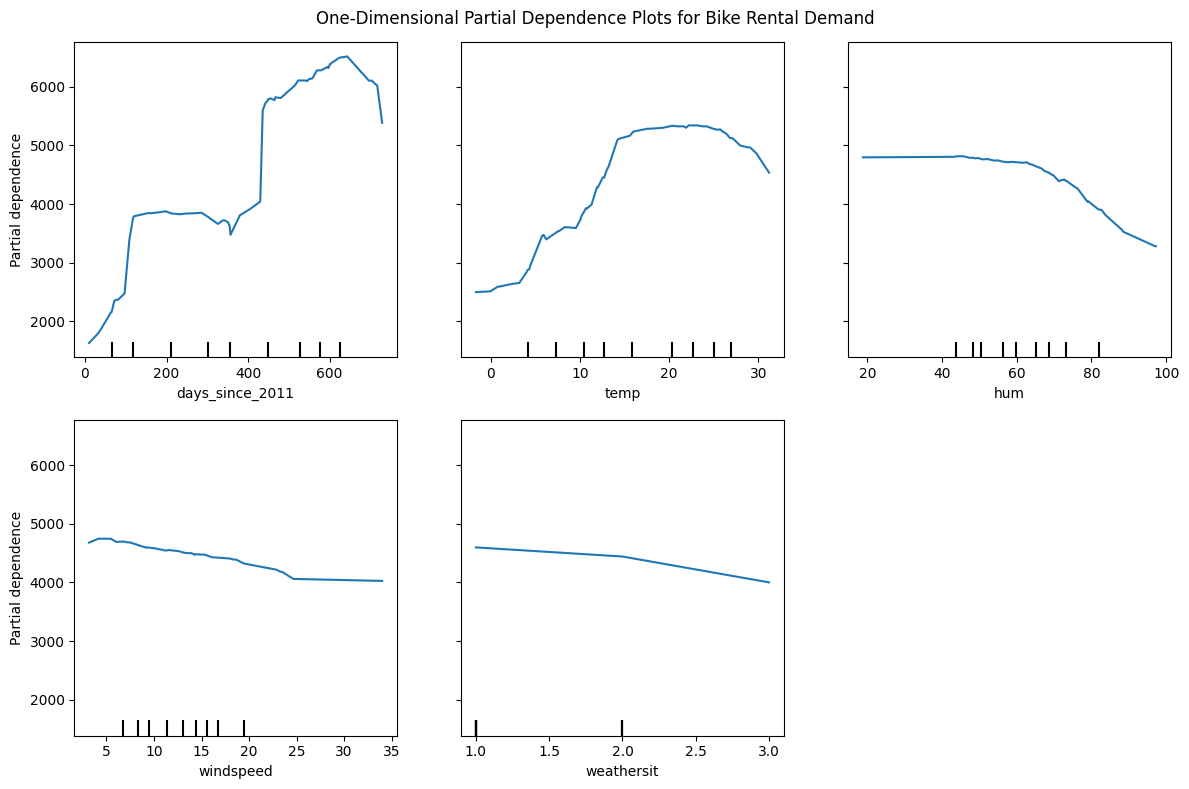

In [11]:
# 1D PDPs for bike rental features
bike_pdp_features_1d = [
    "days_since_2011",
    "temp",
    "hum",
    "windspeed",
    'weathersit'
]

fig, ax = plt.subplots(figsize=(12, 8))

PartialDependenceDisplay.from_estimator(
    bike_rf,
    X_bike_samples,
    bike_pdp_features_1d,
    ax=ax
)

plt.suptitle("One-Dimensional Partial Dependence Plots for Bike Rental Demand")
plt.tight_layout()
plt.show()


## 2D PDP

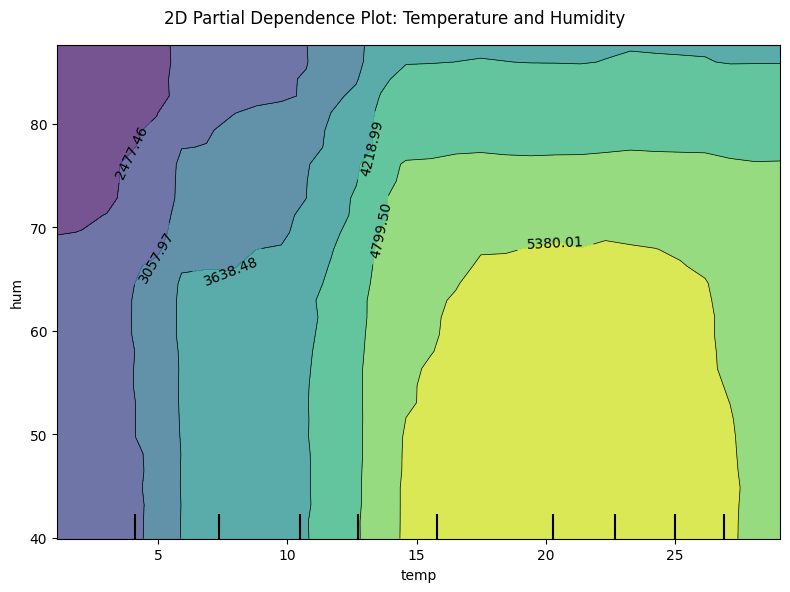

In [12]:
# 2D PDP for temperature and humidity
fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    bike_rf,
    X_bike_samples,
    [("temp", "hum")],
    ax=ax,
    grid_resolution=30
)

plt.suptitle("2D Partial Dependence Plot: Temperature and Humidity")
plt.tight_layout()
plt.show()

## Density Distribution

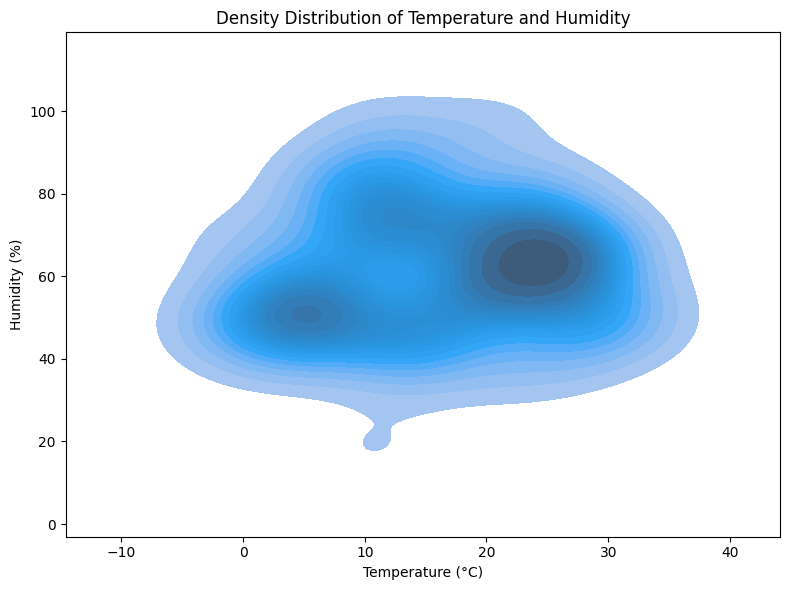

In [13]:
# Density distribution of temperature and humidity in the sampled data
plt.figure(figsize=(8, 6))

sns.kdeplot(
    data=X_bike_samples,
    x="temp",
    y="hum",
    fill=True,
    levels=20,
    thresh=0.05
)

plt.xlabel("Temperature (°C)")
plt.ylabel("Humidity (%)")
plt.title("Density Distribution of Temperature and Humidity")
plt.tight_layout()
plt.show()

## Load Dataset

In [14]:
house_df = pd.read_csv("/content/drive/MyDrive/Colab_Notebooks/EDM2026/Exercises/kc_house_data.csv")
house_df.head()

#from repo
#house_df = pd.read_csv("kc_house_data.csv")

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


## Features

In [15]:
# required features and target variable
house_features = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "yr_built"
]

X_house = house_df[house_features].copy()
y_house = house_df["price"].copy()

## Target variable

In [16]:
# Check target variable
y_house.describe()

,price
count,2.161300e+04
mean,5.400881e+05
std,3.671272e+05
min,7.500000e+04
25%,3.219500e+05
50%,4.500000e+05
75%,6.450000e+05
max,7.700000e+06


## Random sample for PDP

In [17]:
# random sample for PDP computation to reduce runtime
_, X_house_sample, _, y_house_sample = train_test_split(
    X_house,
    y_house,
    test_size=0.08,
    random_state=42
)

print(f"House PDP sample size: {len(X_house_sample)}")

House PDP sample size: 1730


## Random forest

In [18]:
#fit random forest model for house price prediction
house_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

house_rf.fit(X_house_sample, y_house_sample)

RandomForestRegressor(n_jobs=-1, random_state=42)

## 1D PDPs for House features

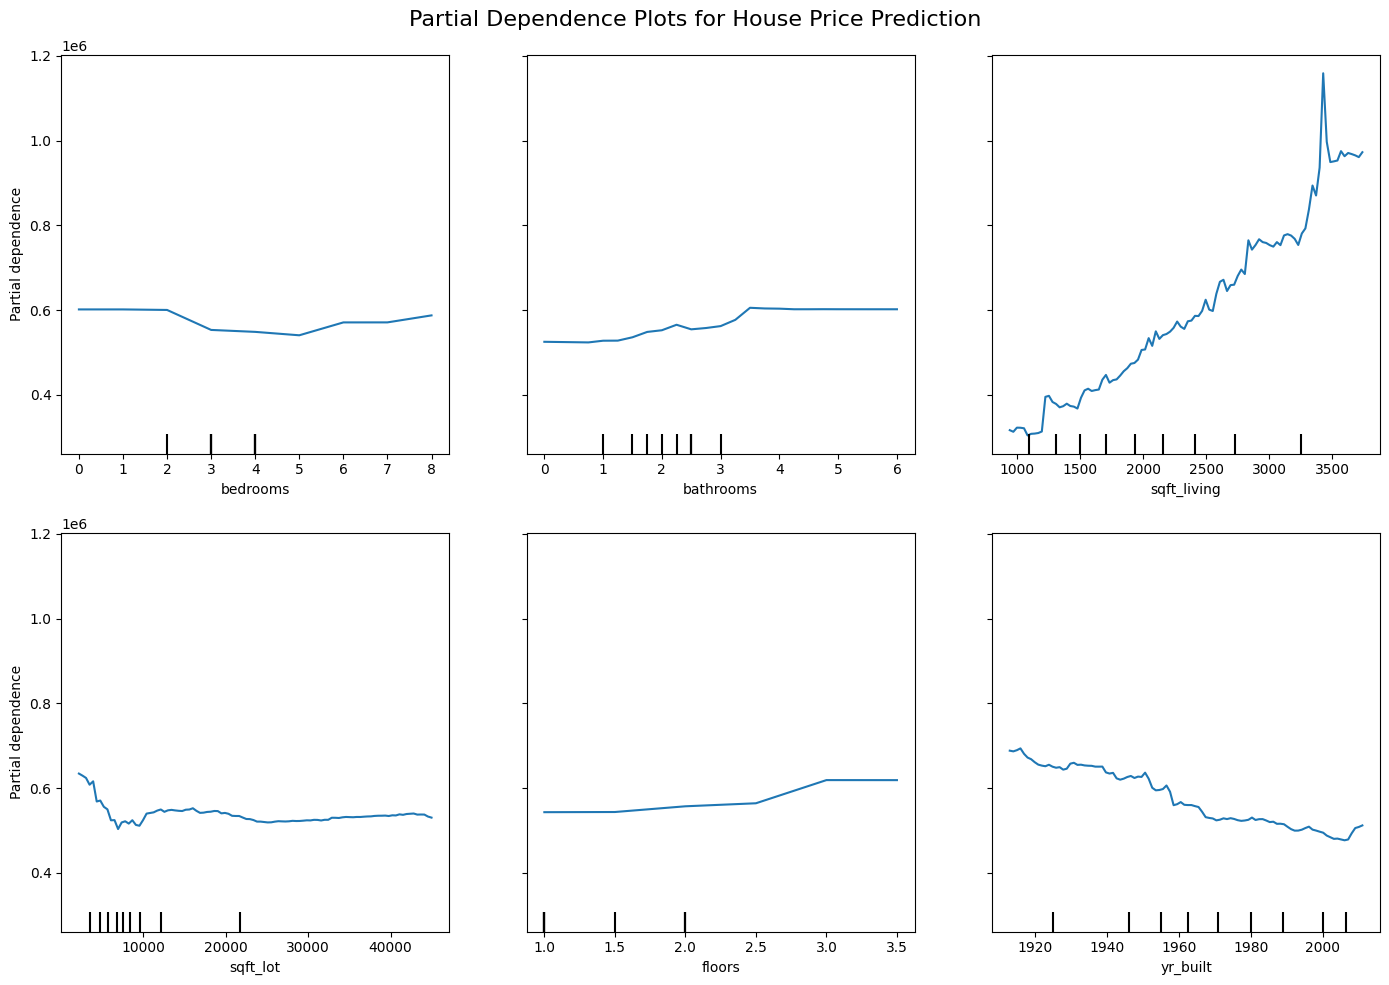

In [19]:
# 1D PDPs for house price model features
house_pdp_features_1d = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "sqft_lot",
    "floors",
    "yr_built"
]

fig, ax = plt.subplots(figsize=(14, 10))

PartialDependenceDisplay.from_estimator(
    house_rf,
    X_house_sample,
    house_pdp_features_1d,
    ax=ax
)

plt.suptitle("Partial Dependence Plots for House Price Prediction", fontsize=16)
plt.tight_layout()
plt.show()